# Tutorial about fluopy - two Cy5 in dSTORM simulation

Here we outline a simulation procedure for a 2-fluorophore Cy5 system under dSTORM conditions.

In [1]:
from pprint import pprint

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import fluopy
import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

In [2]:
fluopy.__version__

'0.1.0.dev218+g6a7acd3b1.d20250915'

In [3]:
rng = np.random.default_rng(seed=1)

## Define the fluorophore system

In [4]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=10, count=2, shape=None
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

In [5]:
pprint(vars(fluorophore_system))

{'count': 2,
 'distances': {(0, 1): np.float64(10.0), (1, 0): np.float64(10.0)},
 'fluorophores': [Fluorophore(identity=0,
                              name='cy5_dna',
                              position=array([0, 0]),
                              constants=FluorophoreData(data_files='cy5_data',
                                                        QUANTUM_YIELD=0.27,
                                                        FLUORESCENCE_LIFETIME=1.7e-09,
                                                        S1_QUENCH_RATE=0,
                                                        ISC_ST_RATE=830000.0,
                                                        ISC_TS_RATE=5000.0,
                                                        RISC_RATE=0,
                                                        STA_EFFICIENCY=0,
                                                        PHOTOBLEACH_T1_RATE=10.0,
                                                        PHOTOBLEACH_T2_RATE=0,
   

## Define the transition set

In [6]:
transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2,
    wavelength=640,
    bleaching=False,
    energy_transfer=True,
    dstorm=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

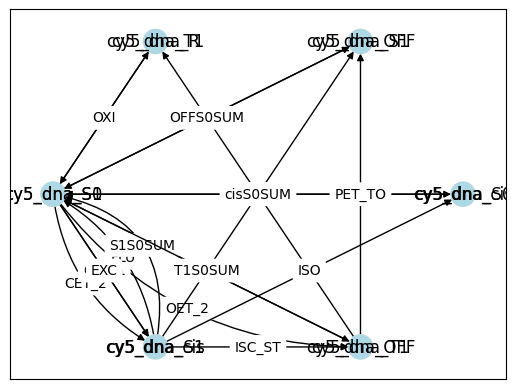

In [7]:
transition_set.plot(graph_type="shell", colors=None, scale=1);

In [8]:
transition_set.transition_df

transition_type  \
Fluorophore                        identity                                           
cy5_dna                            0                      TransitionType.EXCITATION   
                                   1            TransitionType.FLUORESCENT_EMISSION   
                                   2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                   3                   TransitionType.ISOMERIZATION   
                                   4                        TransitionType.ADDUCT_T   
                                   5                        TransitionType.ADDUCT_S   
                                   6                      TransitionType.RAD_ESCAPE   
                                   7                       TransitionType.RAD_RELAX   
                                   8               TransitionType.S1_S0_TRANSITIONS   
                                   9               TransitionType.T1_S0_TRANSITIONS   
                                   10             TransitionType.CIS_S0_TRANSITIONS   
                                   11             TransitionType.OFF_S0_TRANSITIONS   
D: cy5_dna, A: cy5_dna, dist: 10.0 12                     TransitionType.CIS_FRET_1   
                                   13                     TransitionType.CIS_FRET_2   
                                   14                     TransitionType.OFF_FRET_1   
                                   15                     TransitionType.OFF_FRET_2   
                                   16                           TransitionType.FRET   
                                   17               TransitionType.S_S_ANNIHILATION   
                                   18               TransitionType.S_T_ANNIHILATION   

                                            abbreviation       initial_state  \
Fluorophore                        identity                                    
cy5_dna                            0                 EXC      SingleState.S0   
                                   1                 FLU      SingleState.S1   
                                   2              ISC_ST      SingleState.S1   
                                   3                 ISO      SingleState.S1   
                                   4              PET_TO      SingleState.T1   
                                   5              PET_SO      SingleState.S1   
                                   6              PET_TR      SingleState.T1   
                                   7                 OXI       SingleState.R   
                                   8             S1S0SUM      SingleState.S1   
                                   9             T1S0SUM      SingleState.T1   
                                   10           cisS0SUM     SingleState.cis   
                                   11           OFFS0SUM     SingleState.OFF   
D: cy5_dna, A: cy5_dna, dist: 10.0 12              CET_1  PairedState.S1_Cis   
                                   13              CET_2  PairedState.S1_Cis   
                                   14              OET_1  PairedState.S1_OFF   
                                   15              OET_2  PairedState.S1_OFF   
                                   16               FRET   PairedState.S1_S0   
                                   17                SSA   PairedState.S1_S1   
                                   18                STA   PairedState.S1_T1   

                                                    final_state          rate  \
Fluorophore                        identity                                     
cy5_dna                            0             SingleState.S1  5.815700e+06   
                                   1             SingleState.S0  1.588235e+08   
                                   2             SingleState.T1  8.300000e+05   
                                   3            SingleState.cis  4.000000e+06   
                                   4            SingleState.OFF  4.383440

## Make a prediction

In [9]:
%%time
prediction = pr.Prediction(transition_set)
prediction

prediction accuracy of energy transfers more difficult to tune. Only frequencies available, lifetimes and occupations not available.


CPU times: total: 15.6 ms
Wall time: 13.4 ms


array([[<Axes: ylabel='Prob. occurrence'>]], dtype=object)

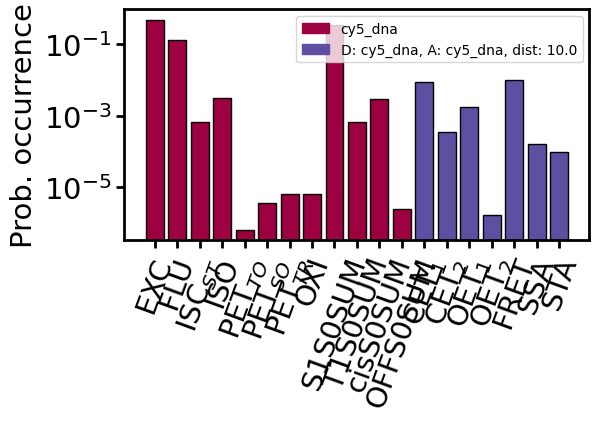

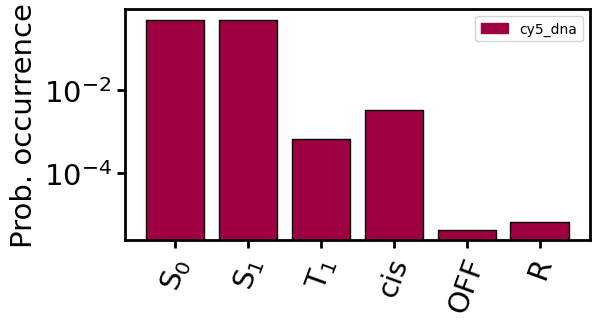

In [10]:
prediction.plot_frequency_transitions(scale=1)
prediction.plot_frequency_states(scale=1)

## Run a simulation

In [11]:
simulation = si.Simulation(transition_set)
simulation

In [12]:
%%time
# simulate until it reaches given end_time
simulation.run(start_at=None, size=1e6, end_time=500, seed=rng, use_memmap=None)
mi.print_class(simulation)

Floating point precision error warning:
 The smallest safe increment is 5.68e-14.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1]
 gives a probability of 7.75e-05 for a smaller increment to be drawn.


Attributes of <fluopy.simulation.Simulation object at 0x00000256BBB338C0>:
.................................................................
transition_set = <fluopy.transitions.TransitionSet object at 0x00000256BBB31550>
_________________________________________________________________
time_series = array([0.00000000e+00, 5.75837004e-08, 6.0586144...81150266e+02, 5.00000000e+02], shape=(22687295,))
_________________________________________________________________
transition_series = array([  0,  96,   1, ..., 106,  10,  70], shape=(22687293,), dtype=uint32)
_________________________________________________________________
state_series = array([[0, 0, 0, ..., 7, 7, 7],
       [0, 1, 0, ..., 0, 1, 7]], shape=(2, 22687294), dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________


CPU times: total: 1min 36s
Wall time: 1min 37s


## Analyze the simulation

In [13]:
analysis = an.Analysis(simulation=simulation)
mi.print_class(analysis)

Attributes of <fluopy.analysis.Analysis object at 0x00000256BBB33380>:
.................................................................
simulation = <fluopy.simulation.Simulation object at 0x00000256BBB338C0>
_________________________________________________________________
frequency_transitions = array([4.93169767e-01, 1.29110335e-01, 6.7883815... 1.00874088e-02, 1.63792128e-04, 1.00144164e-04])
_________________________________________________________________
frequency_states = {'cy5_dna': array([4.98053379e-01, 4.98053379e-01, 6.7181880...3435e-03,
       3.44611944e-06, 6.54326476e-06])}
_________________________________________________________________
transition_time_distributions = [array([1.60771192e-07, 5.14620749e-08, 2.7001028...86329713e-08, 9.42114298e-08], shape=(11188687,)), array([2.46836785e-09, 5.99342571e-12, 1.9523953....70265604e-10, 3.42532758e-09], shape=(2929164,)), array([3.32554442e-09, 1.21016084e-09, 1.7050239... 3.57761110e-09, 1.22037136e-09], shape=(15401

array([[<Axes: ylabel='Prob. occurrence'>]], dtype=object)

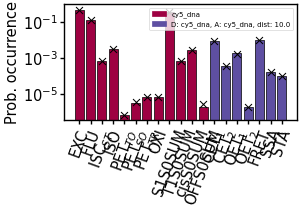

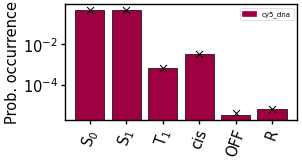

In [14]:
analysis.get_fluorescence_lifetimes(fluorophore="cy5_dna")
analysis.get_emitting_transition_lifetimes(fluorophore="cy5_dna")

analysis.plot_frequency_transitions(scale=0.5, prediction=prediction)
analysis.plot_frequency_states(scale=0.5, prediction=prediction)
# analysis.plot_mean_transition_times(scale=0.5, prediction=prediction)
# analysis.plot_mean_lifetimes(scale=0.5, prediction=prediction)
# analysis.plot_state_occupations(scale=0.5, prediction=prediction)
# analysis.plot_lifetime_distributions(
#    scale=0.5, prediction=prediction, fluorophore="cy5_dna", state_identity=1
# )
# analysis.plot_transition_time_distributions(
#    scale=0.5, prediction=prediction, fluorophore="cy5_dna", transition_id=0
# )

## Simulation of experimentally observable (photons per frames) only

#### Extract photon emission events from simulation

In [15]:
%%time
emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(600, 800))
emissions.extract(simulation=simulation)
emissions

CPU times: total: 1.47 s
Wall time: 1.48 s


#### Simulate photon emission events

Correct for detection efficiency and noise contributions:

In [16]:
emissions.add_photon_collection_objective(p=0.1, seed=rng)  # 1.
emissions.add_quantum_efficiency(p=0.9, seed=rng)  # 3.1.
emissions.add_poisson_noise(
    rate=0.05, seed=rng
)  # 3.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10, seed=rng)  # 4.
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 5. (readout noise)
emissions

emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(660, 700))
emissions.extract(simulation=approximation)  

In [17]:
# 2.
# at this point, the bandpass filter was applied
# yet, the effect of photon collection by the objective is missing
# the order is not relevant for two consecutive binomial distributions
# it is more convenient to apply the bandpass first because it needs the
# information about the emitting fluorophore whereas all the other effects are
# roughly wavelength independent
p_photon_collection = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emissions.add_photon_collection_objective(p=p_photon_collection)  # 1.
emissions.add_quantum_efficiency(p=0.9)  # 4.1.
emissions.add_transmittance(p=0.99)  # 3 (depending on number of components of optical
# path, may be applied multiple times)
emissions.add_poisson_noise(rate=0.05)  # 4.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10)  # 5. (+ multiplicative noise)
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 6. (readout noise)
# CIC (spurious noise) neglected since low probability to happen in the pixels of
# interest
emissions.apply_threshold(threshold=100)  # 7 (thresholding)

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

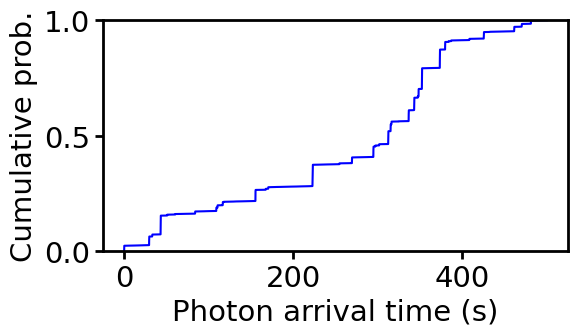

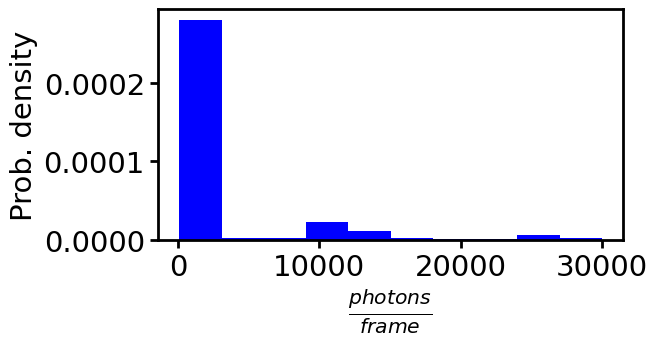

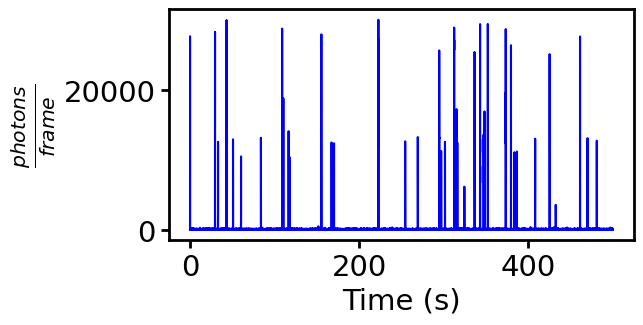

In [18]:
emissions.plot_cumulative_events(scale=1)
emissions.plot_histogram(scale=1)
emissions.plot_time_series(scale=1)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')

## Simulation of pulsed excitation

In [19]:
%%time
emissions_tcspc = em.Emissions(frame_time="1ms", seed=rng, bandpass=None)
lifetimes_DA, lifetimes_D, lifetimes_all = emissions_tcspc.tcspc(
    transition_set=transition_set,
    number_pulses=5e5,
    pulse_duration=1e-11,
    time_between_pulses=1e-7,
    excitation_rates={"cy5_dna": 1e11},
    size=1e5,
    store_time_points=True,
    # details = True
)

the last frame (of index 0.05) has 1.00e+00 times the pulses of other frames.


CPU times: total: 49.7 s
Wall time: 50 s


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

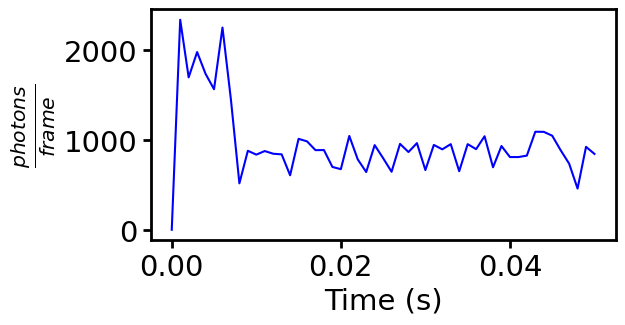

In [20]:
emissions_tcspc.plot_time_series()

array([[<Axes: xlabel='Lifetime (s)', ylabel='PD'>]], dtype=object)

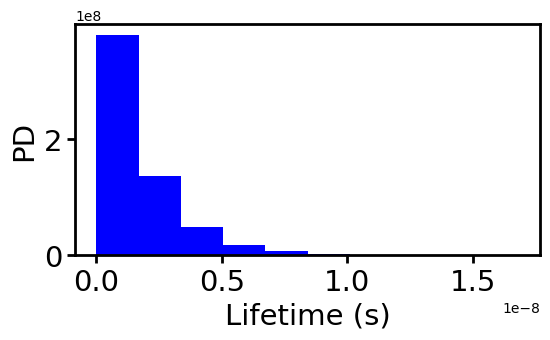

In [21]:
fi.universal_figure(
    type_="hist", data=lifetimes_all, ylabel="PD", density=True, xlabel="Lifetime (s)"
)

## Fluorescence correlation spectroscopy

Observed fluorescence emission events can be analyzed by a correlation analysis.

In [22]:
fcs = fcs_p.FCS(emissions)
list(vars(fcs).keys())

['emissions', 'autocorrelation', 'tau']

### Autocorrelation of time points

In [23]:
%%time
fcs.autocorrelate_time_points(
    exp_min=-20, exp_max=-6, points_per_base=4, base=4, normalize=True
)

CPU times: total: 5.47 s
Wall time: 6.25 s


Attributes of <fluopy.fcs.FCS object at 0x00000256BBB31FD0>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000256BBB317F0>
_________________________________________________________________
autocorrelation = array([  0.        , 105.25773385,  74.42845738,...37465, 195.96795256, 195.71451995, 194.70409197])
_________________________________________________________________
tau = array([1.09785722e-12, 1.55260457e-12, 2.1957144... 1.04193529e-04, 1.47351902e-04, 2.08387058e-04])
_________________________________________________________________




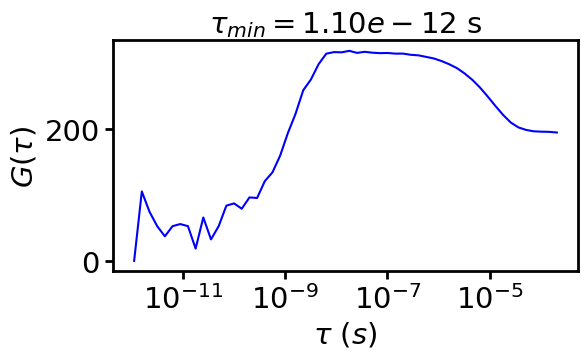

In [24]:
mi.print_class(fcs)
fcs.plot(normalize_to=None, unit="s", scale=1);

### Autocorrelation of time series

In [25]:
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

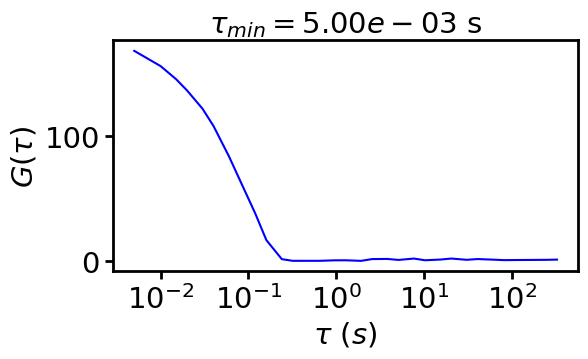

In [26]:
fcs.plot(normalize_to=None, unit="s", scale=1);

In [27]:
# some fcs fits are available:
# fcs_predict = fcs_p.fit_dark(tau, dark_lifetime, dark_occupation)
# fcs_predict = fcs_p.fit_antibunching(tau, excitation_rate, s1_lifetime)
# fcs_predict = fcs_p.fit_triplet_cis(tau, k_isc, k_T, k_01, k_10, k_iso, k_biso_eff)

## Antibunching

Alternatively, you can focus on fast time scales in a linear scale and observe antibunching.

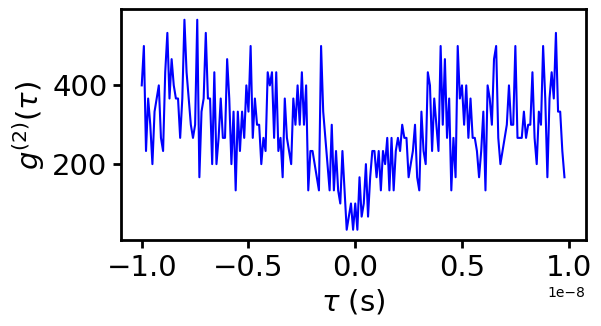

In [28]:
# sensible to tau_max and bin_width, see coincidence notebook
hist, bins = fcs_p.coincidence(
    emissions.event_time_points[: int(2e5)], tau_max=1e-8, bin_width=1e-10, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bins[:-2], hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    scale=1,
);

## Blinking

### Emissions from a short simulation

We limit the dataset to 2000 frames for illustration purposes.

In [29]:
%%time
emissions = em.Emissions(frame_time="10ms", seed=rng, bandpass=None)
emissions.simulate(
    transition_set=transition_set, store_time_points=False, frames=10_000
)
emissions

CPU times: total: 13.2 s
Wall time: 13.3 s


In [30]:
threshold: int = 1000

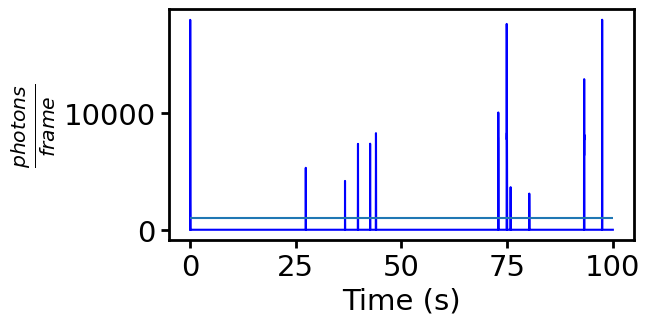

In [31]:
emissions.plot_time_series(scale=1)
plt.hlines(threshold, xmin=0, xmax=100)

In [32]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [33]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x00000256BBB31160>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000256C4F30910>
_________________________________________________________________
on_periods = array([ 7,  2,  2,  4,  3,  6,  5, 11,  1,  2,  8,  5])
_________________________________________________________________
off_periods = array([2727,  927,  302,  285,  133, 2890,  193,   84,  440, 1293,  418])
_________________________________________________________________
on_periods_frames = array([   1, 2735, 3664, 3968, 4257, 4393, 7289, 7487, 7582, 8023, 9318,
       9744])
_________________________________________________________________
off_periods_frames = array([   8, 2737, 3666, 3972, 4260, 4399, 7294, 7498, 7583, 8025, 9326])
_________________________________________________________________




array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

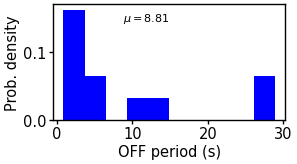

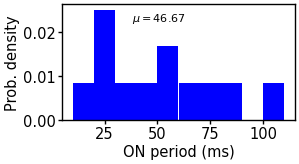

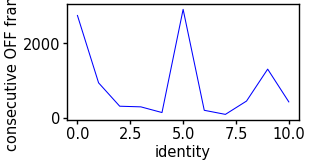

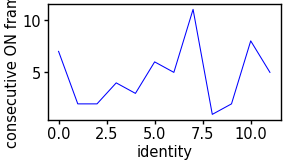

In [34]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

array([[<Axes: title={'center': 'analytical OFF'}, xlabel='time [s]'>]],
      dtype=object)

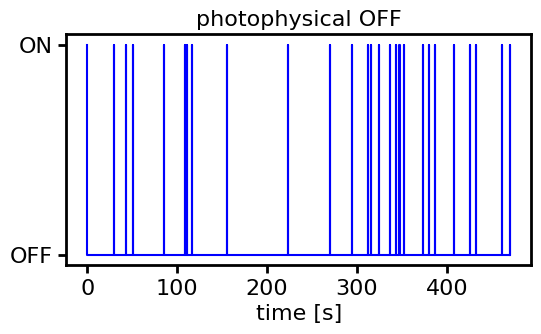

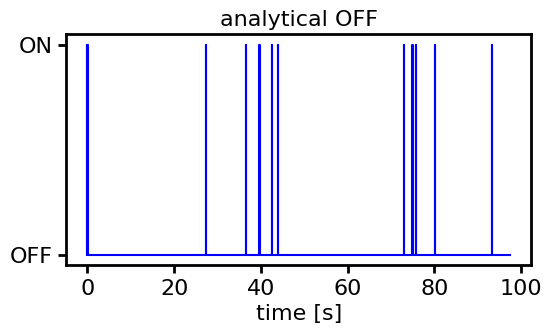

In [35]:
# to get information of the photophysical (not analytical) OFF of each fluorophore, use
on_off_times_photophys, on_off_values_photophys = bl.get_off_statistics(
    simulation=simulation, index=0
)

# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the photophysical OFF statistics
bl.plot_off_statistics(
    on_off_times_photophys,
    on_off_values_photophys,
    scale=1,
    title="photophysical OFF",
)
# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=1, title="analytical OFF"
)

### Emissions from the long simulation

Get more detailed information from a complete simulation:

In [36]:
%%time
emissions = em.Emissions(frame_time="10ms", seed=rng, bandpass=None)
emissions.extract(simulation=simulation)
emissions

CPU times: total: 1.47 s
Wall time: 1.47 s


In [37]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [38]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x00000256C50702D0>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000256C2C769E0>
_________________________________________________________________
on_periods = array([ 6, 12,  4, 22,  2,  1,  4,  5,  4,  7,  ..., 21,  9,  2,  2,  3,
       10,  1,  7,  6,  6])
_________________________________________________________________
off_periods = array([2945,  351,  991,  755,  948, 2349, 2504,... 293, 2152,
       1705,  713, 2872,  881, 1087])
_________________________________________________________________
on_periods_frames = array([    1,  2952,  3315,  4310,  5087,  6037,...40825, 42533, 43256,
       46129, 47017, 48110])
_________________________________________________________________
off_periods_frames = array([    7,  2964,  3319,  4332,  5089,  6038,...38673, 40828, 42543, 43257,
       46136, 47023])
_________________________________________________________

array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

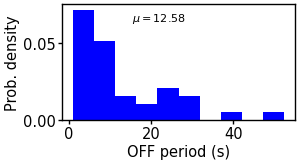

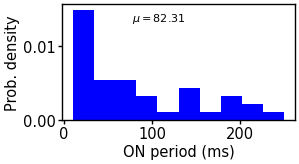

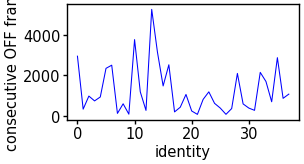

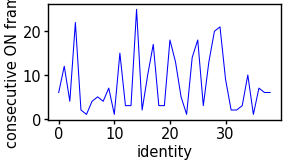

In [39]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

array([[<Axes: title={'center': 'analytical OFF'}, xlabel='time [s]'>]],
      dtype=object)

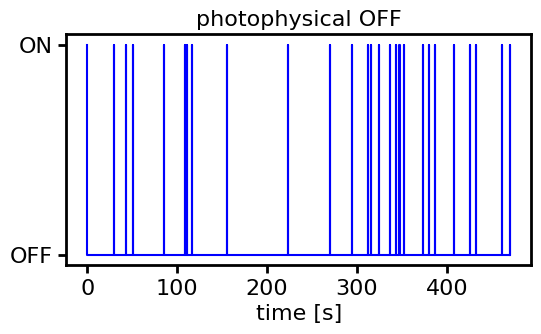

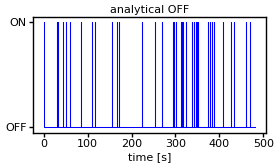

In [40]:
# to get information of the photophysical (not analytical) OFF of each fluorophore, use
on_off_times_photophys, on_off_values_photophys = bl.get_off_statistics(
    simulation=simulation, index=0
)

# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the photophysical OFF statistics
bl.plot_off_statistics(
    on_off_times_photophys,
    on_off_values_photophys,
    scale=1,
    title="photophysical OFF",
)
# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=0.5, title="analytical OFF"
)